In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train = pd.read_csv("../dataset/cleaned/train_processed.csv")

train.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,...,GarageQual_Fa,GarageQual_TA,GarageCond_Fa,GarageCond_TA,PavedDrive_Y,SaleType_New,SaleType_WD,SaleCondition_Normal,SaleCondition_Partial,SalePrice
0,-0.237456,-0.333244,0.652644,-0.564161,1.053246,0.878668,1.224128,0.614224,-0.958790,-0.488321,...,-0.203801,0.290522,-0.170457,0.276034,0.261789,-0.359481,0.329514,0.383663,-0.365276,208500.0
1,0.633321,-0.013189,-0.073068,2.030907,0.156179,-0.429577,-0.813256,1.242296,-0.648290,0.532289,...,-0.203801,0.290522,-0.170457,0.276034,0.261789,-0.359481,0.329514,0.383663,-0.365276,181500.0
2,-0.063300,0.446022,0.652644,-0.564161,0.986797,0.830215,1.151068,0.106224,-0.300716,-0.327437,...,-0.203801,0.290522,-0.170457,0.276034,0.261789,-0.359481,0.329514,0.383663,-0.365276,223500.0
3,-0.527714,-0.027104,0.652644,-0.564161,-1.870528,-0.720298,-0.813256,-0.517230,-0.055097,-0.739702,...,-0.203801,0.290522,-0.170457,0.276034,0.261789,-0.359481,0.329514,NaN,-0.365276,140000.0
4,0.865528,1.283733,1.378355,-0.564161,0.953572,0.733308,1.446863,0.496460,-0.170955,0.238172,...,-0.203801,0.290522,-0.170457,0.276034,0.261789,-0.359481,0.329514,0.383663,-0.365276,250000.0


In [8]:
correlation = train.corr()["SalePrice"]

correlation.sort_values(ascending=False)

SalePrice               1.000000
OverallQual             0.817680
GrLivArea               0.729311
GarageCars              0.675896
GarageArea              0.660029
                          ...   
GarageQual_TA                NaN
GarageCond_TA                NaN
PavedDrive_Y                 NaN
SaleType_WD                  NaN
SaleCondition_Normal         NaN
Name: SalePrice, Length: 109, dtype: float64

In [23]:
correlation.abs()

LotFrontage              0.375850
LotArea                  0.435876
OverallQual              0.817680
OverallCond              0.105920
YearBuilt                0.570327
                           ...   
SaleType_New             0.344744
SaleType_WD                   NaN
SaleCondition_Normal          NaN
SaleCondition_Partial    0.339549
SalePrice                1.000000
Name: SalePrice, Length: 109, dtype: float64

In [9]:
top_features = correlation.abs().sort_values(ascending=False).index[1:6]

top_features

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF'], dtype='str')

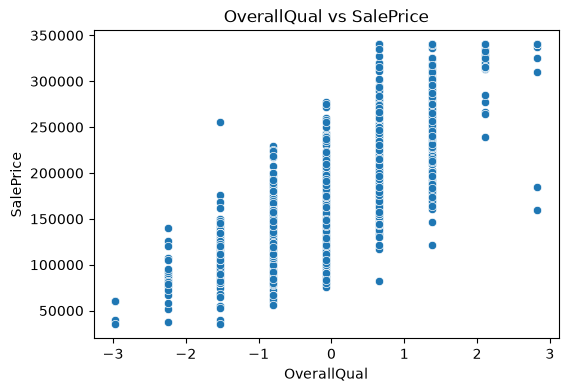

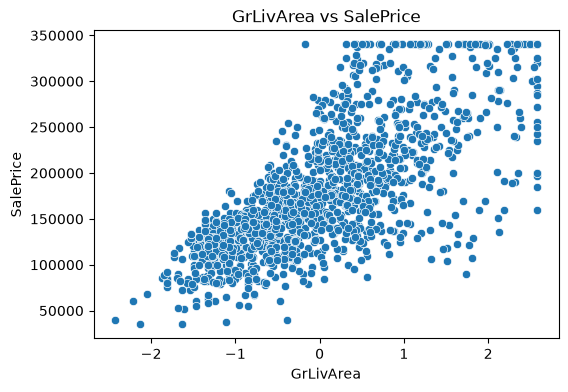

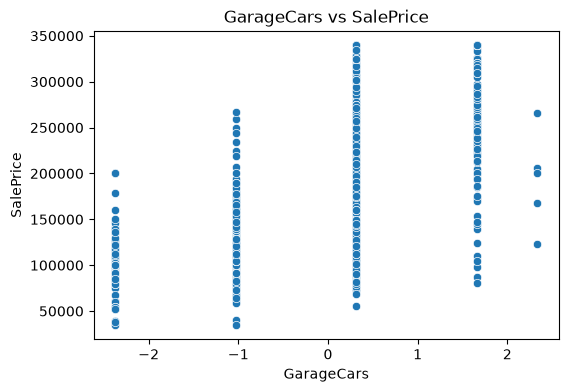

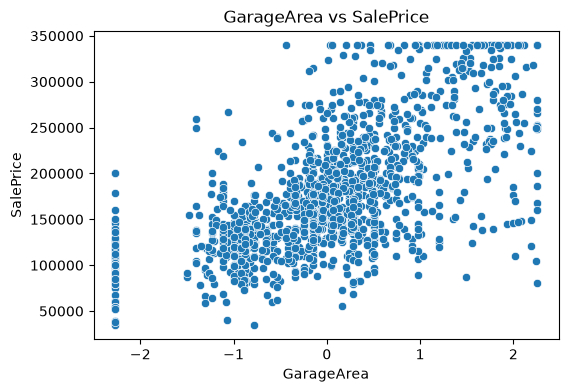

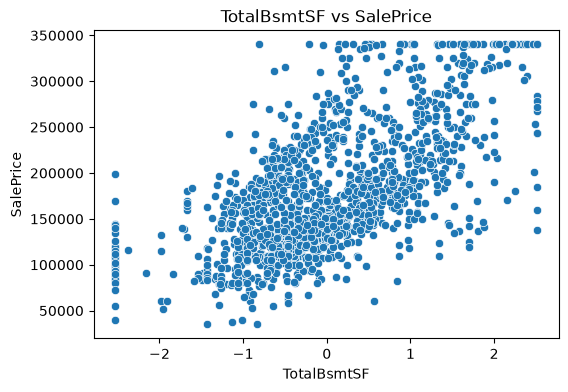

In [10]:
for column in top_features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=train[column],
        y=train["SalePrice"]
    )

    plt.title(f"{column} vs SalePrice")

    plt.show()

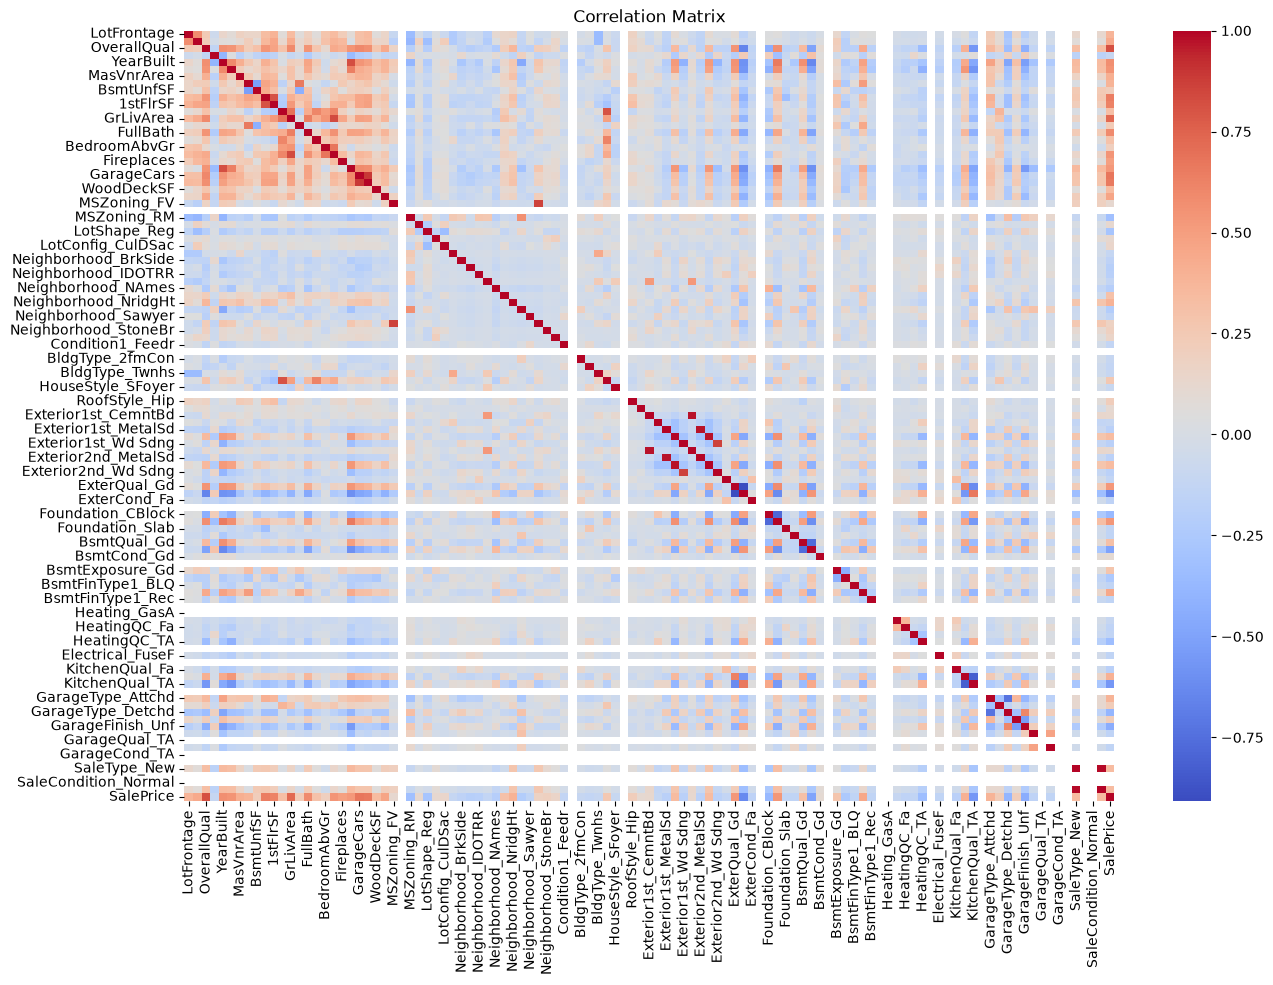

In [11]:
plt.figure(figsize=(15,10))

sns.heatmap(
    train.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [12]:
correlation.sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.817680
GrLivArea       0.729311
GarageCars      0.675896
GarageArea      0.660029
TotalBsmtSF     0.645251
1stFlrSF        0.621873
FullBath        0.583994
YearBuilt       0.570327
YearRemodAdd    0.552061
Name: SalePrice, dtype: float64

In [13]:
correlation.sort_values().head(10)

ExterQual_TA        -0.630016
KitchenQual_TA      -0.561153
BsmtQual_TA         -0.490576
GarageFinish_Unf    -0.444460
GarageType_Detchd   -0.389651
Foundation_CBlock   -0.362833
HeatingQC_TA        -0.336409
MSZoning_RM         -0.323491
LotShape_Reg        -0.282544
BsmtExposure_No     -0.254479
Name: SalePrice, dtype: float64

In [33]:
important_features = [
    "GrLivArea",
    "TotalBsmtSF",
    "GarageArea",
    "SalePrice",
    "GarageCars",
    "OverallQual"
]

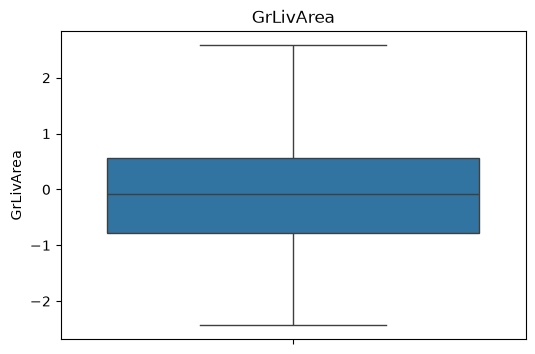

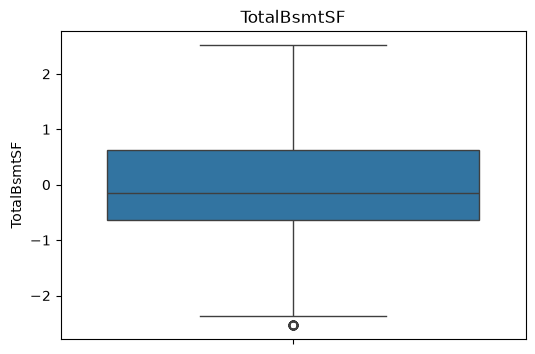

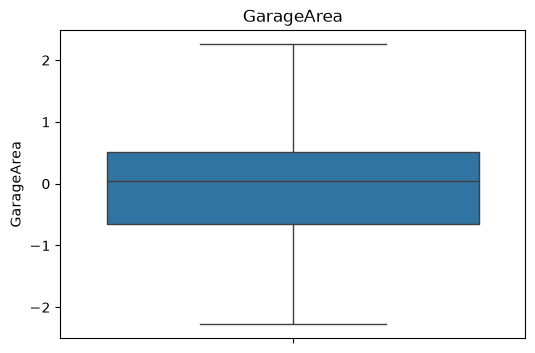

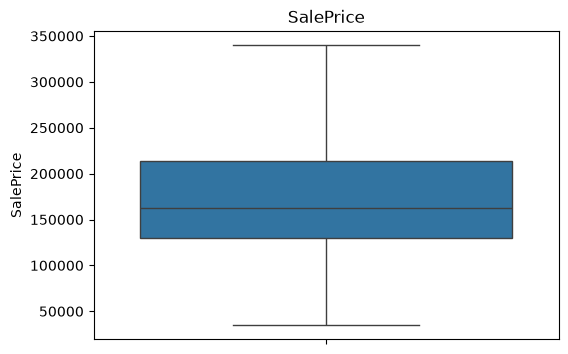

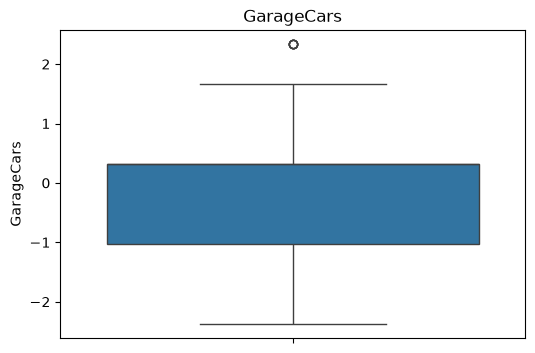

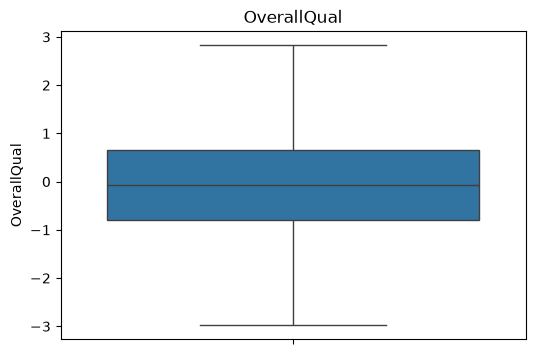

In [34]:
for column in important_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        y=train[column]
    )

    plt.title(column)

    plt.show()

In [26]:
feature_importance = correlation.abs().sort_values(
    ascending=False
)

feature_importance.head(15)

SalePrice           1.000000
OverallQual         0.817680
GrLivArea           0.729311
GarageCars          0.675896
GarageArea          0.660029
TotalBsmtSF         0.645251
ExterQual_TA        0.630016
1stFlrSF            0.621873
FullBath            0.583994
YearBuilt           0.570327
KitchenQual_TA      0.561153
YearRemodAdd        0.552061
TotRmsAbvGrd        0.539339
Foundation_PConc    0.535107
ExterQual_Gd        0.526232
Name: SalePrice, dtype: float64

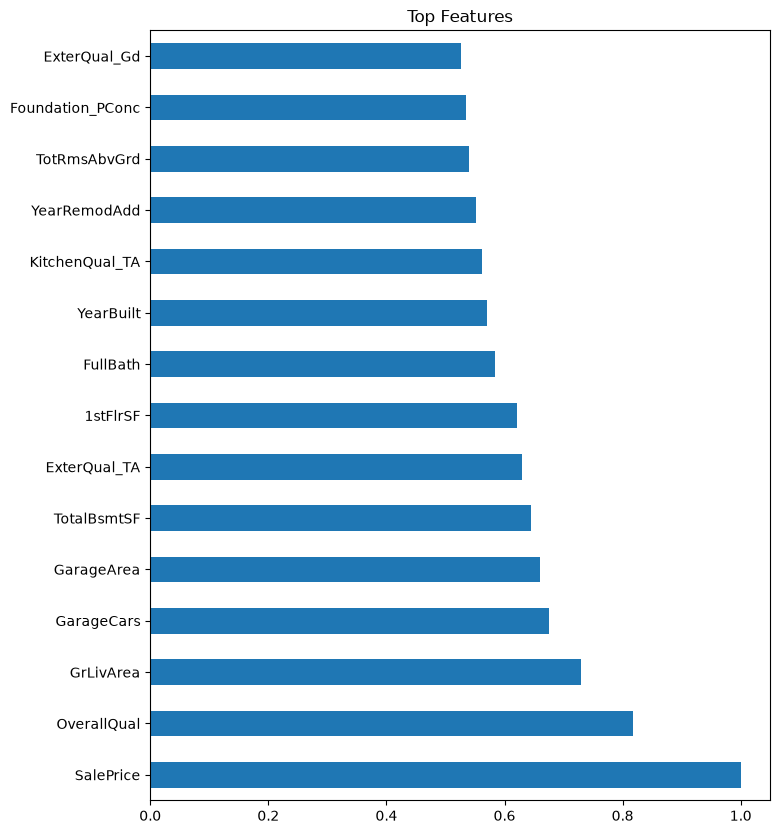

In [27]:
plt.figure(figsize=(8,10))

feature_importance.head(15).plot(
    kind="barh"
)

plt.title("Top Features")

plt.show()

In [ ]:
selected_columns = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "SalePrice"
]   

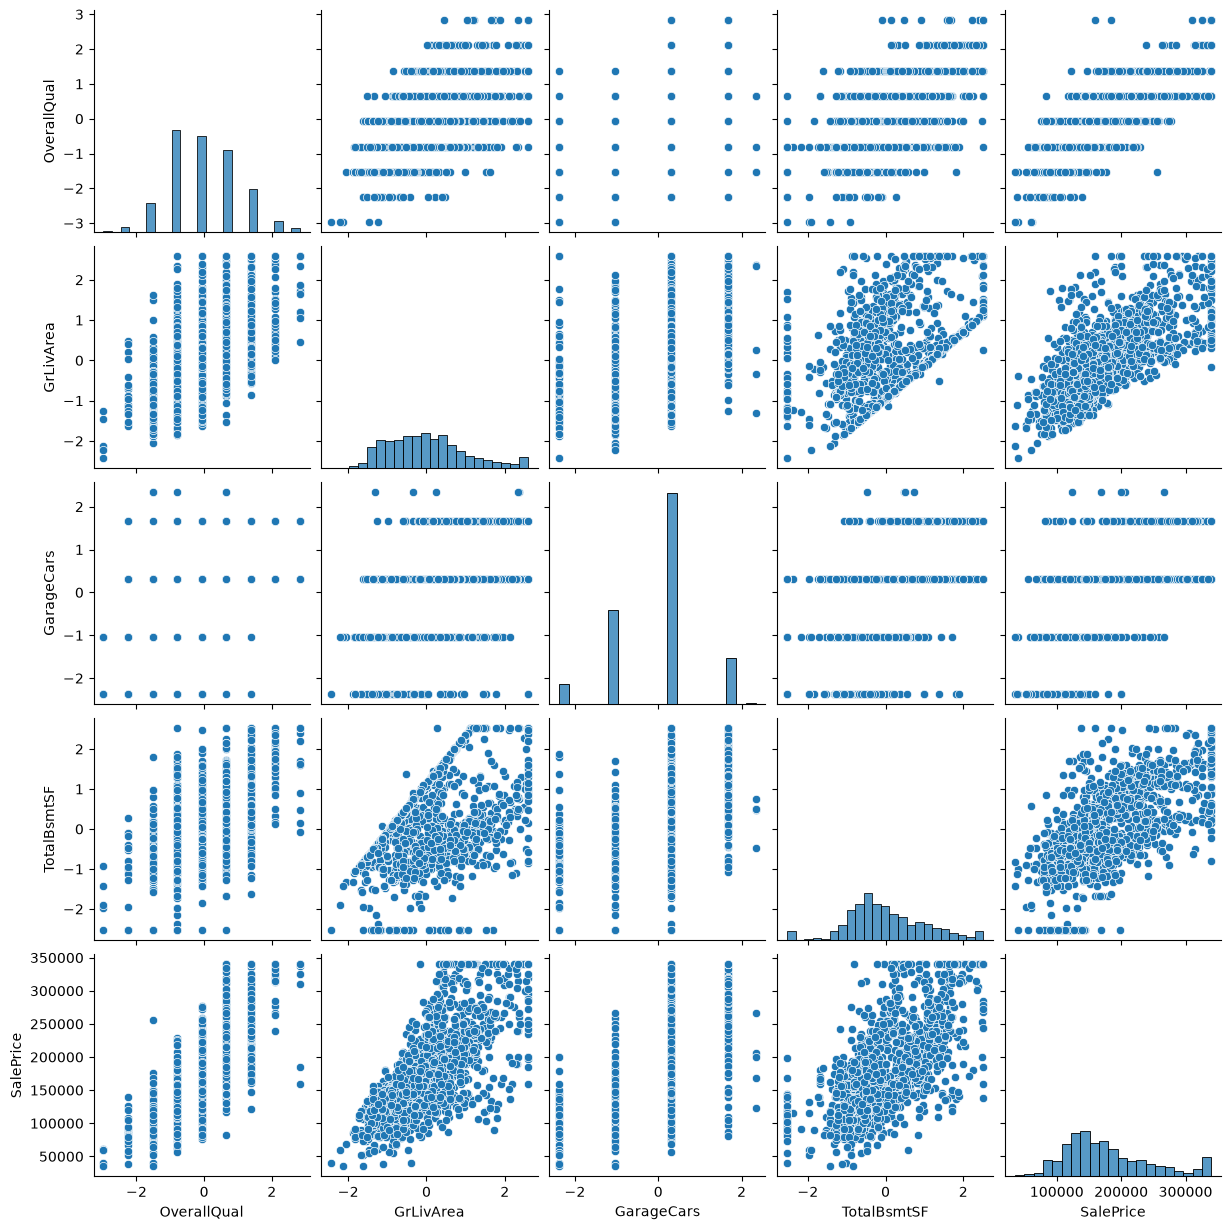

In [29]:
sns.pairplot(train[selected_columns])

plt.show()

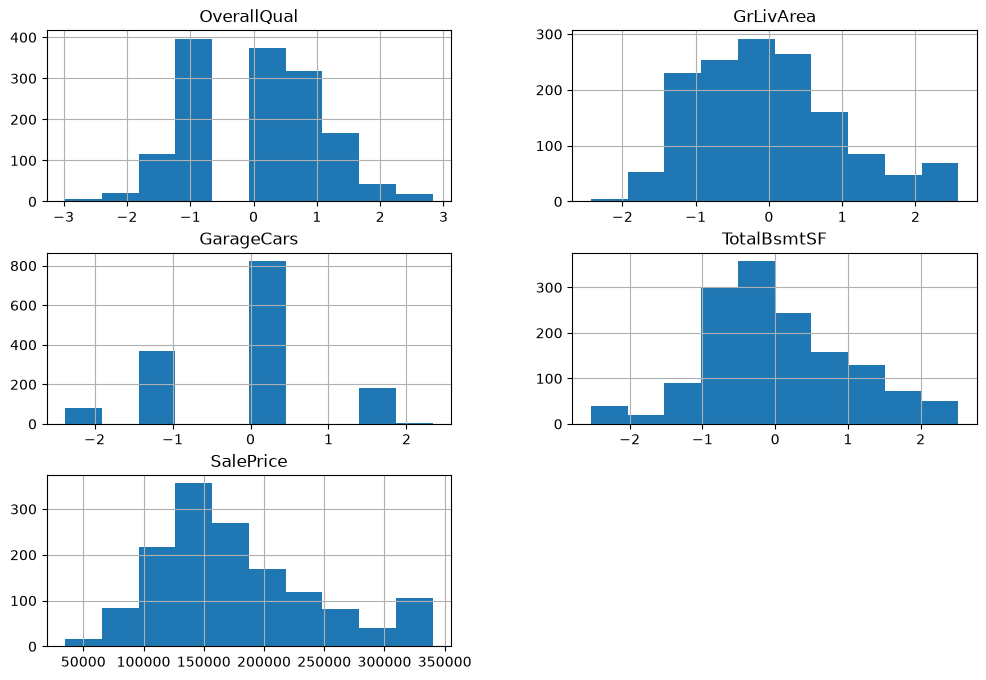

In [30]:
train[selected_columns].hist(
    figsize=(12,8)
)

plt.show()

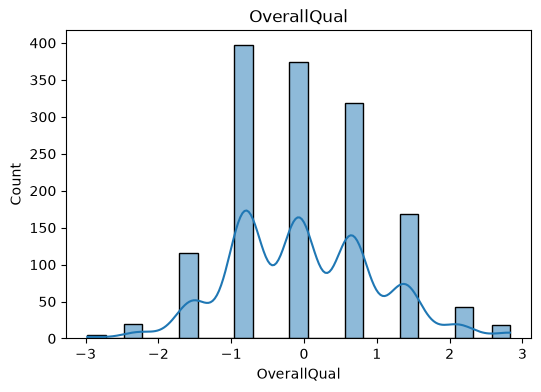

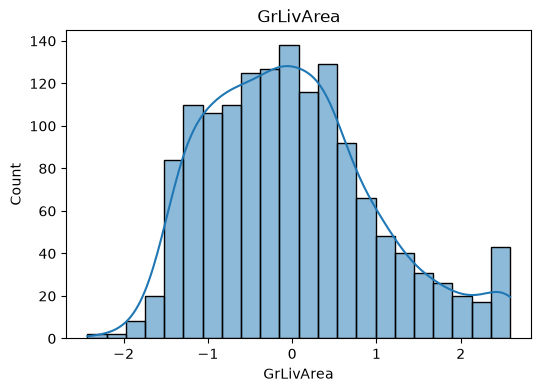

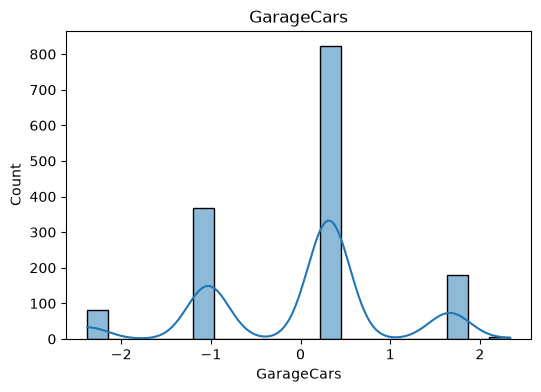

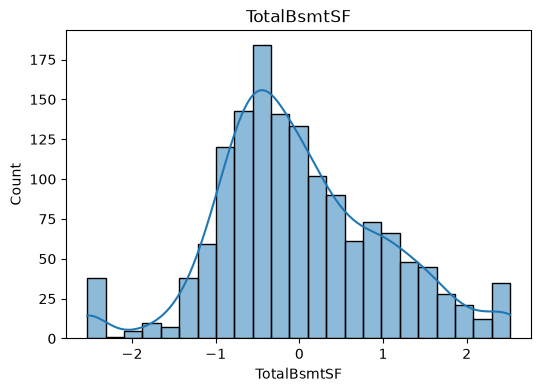

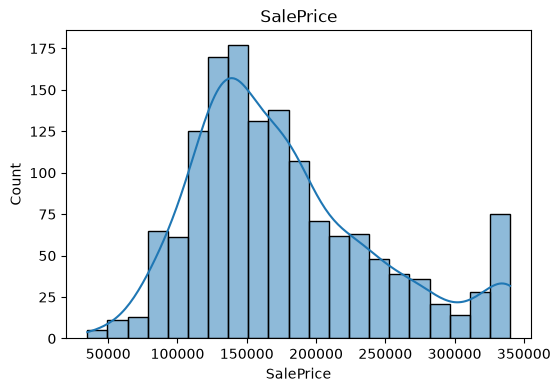

In [31]:
for column in selected_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(
        train[column],
        kde=True
    )

    plt.title(column)

    plt.show()

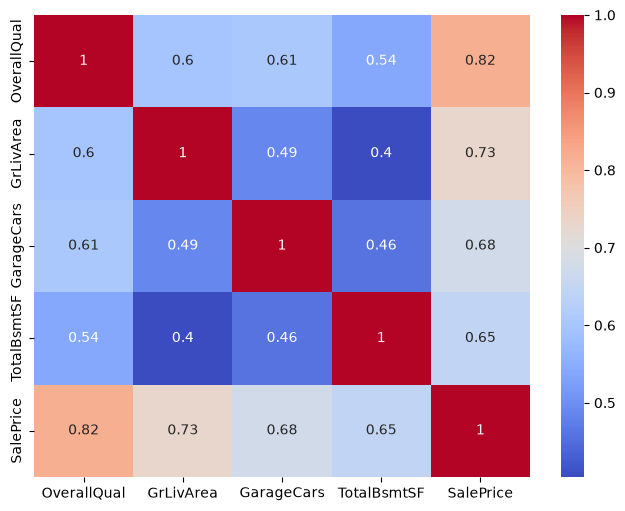

In [32]:
plt.figure(figsize=(8,6))

sns.heatmap(
    train[selected_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()